15. This problem involves the Boston data set, which we saw in the lab
for this chapter. We will now try to predict per capita crime rate
using the other variables in this data set. In other words, per capita
crime rate is the response, and the other variables are the predictors.
(a) For each predictor, fit a simple linear regression model to predict
the response. Describe your results. In which of the models is
there a statistically significant association between the predictor
and the response? Create some plots to back up your assertions.

(a) Univariate OLS (sorted by p-value)
 Predictor  Coefficient     P-value  R-squared
       rad     0.617911 2.69384e-56   0.391257
       tax    0.0297423 2.35713e-47   0.339614
     lstat     0.548805 2.65428e-27   0.207591
       nox      31.2485 3.75174e-23   0.177217
Unnamed: 0    0.0239672 1.18212e-21   0.165981
     indus     0.509776 1.45035e-21    0.16531
      medv     -0.36316 1.17399e-19    0.15078
       dis      -1.5509 8.51995e-19   0.144149
       age     0.107786 2.85487e-16   0.124421
   ptratio      1.15198 2.94292e-11  0.0840684
        rm     -2.68405  6.3467e-07  0.0480691
        zn    -0.073935 5.50647e-06  0.0401879
      chas     -1.89278    0.209435 0.00312387


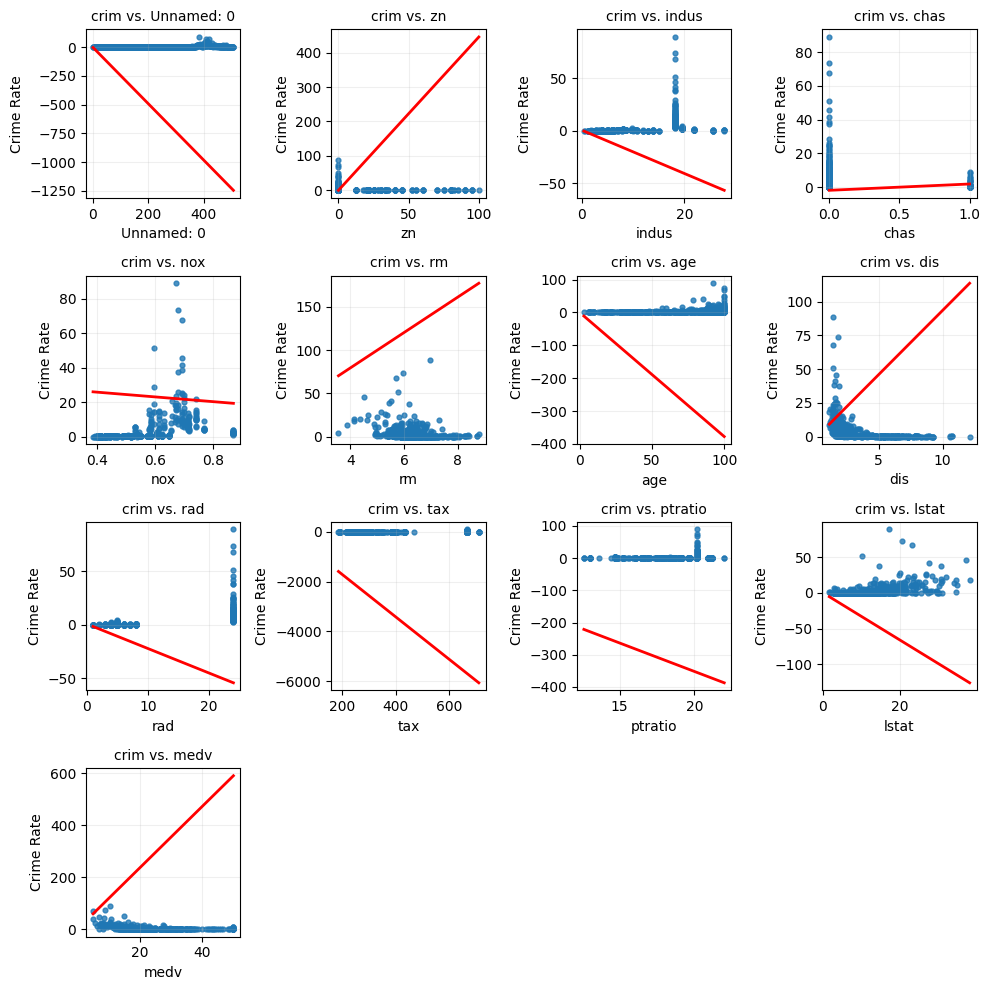

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

boston = pd.read_csv("Boston.csv")
# 用你已讀好的資料框：boston
df = boston.copy()

y = df["crim"].values
Xcols = [c for c in df.columns if c != "crim"]  # 其他欄全當 predictor

# --- 逐一配適：crim ~ Xj ---
rows = []
for v in Xcols:
    X = sm.add_constant(df[[v]])
    m = sm.OLS(y, X).fit()
    rows.append({"Predictor": v,
                 "Coefficient": m.params[v],
                 "P-value": m.pvalues[v],
                 "R-squared": m.rsquared})

uni_df = (pd.DataFrame(rows)
            .sort_values("P-value")
            .reset_index(drop=True))

pd.set_option("display.float_format", "{:.6g}".format)
print("(a) Univariate OLS (sorted by p-value)")
print(uni_df.to_string(index=False))

cols = 4
n = len(Xcols)
r = int(np.ceil(n/cols))
plt.figure(figsize=(10, 10))
for i, v in enumerate(Xcols, 1):
    x = df[v].values
    b0, b1 = np.polyfit(x, y, 1)  # y ≈ b0 + b1*x
    xx = np.linspace(x.min(), x.max(), 200)

    ax = plt.subplot(r, cols, i)
    ax.scatter(x, y, s=12, alpha=0.8)
    ax.plot(xx, b0 + b1*xx, color="red", linewidth=2)
    ax.set_title(f"crim vs. {v}", fontsize=10)
    ax.set_xlabel(v); ax.set_ylabel("Crime Rate")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


Direction: Positive — rad, tax, lstat, nox, indus, age, ptratio. Negative — medv, dis, rm, zn.

(b) Fit a multiple regression model to predict the response using
all of the predictors. Describe your results. For

In [3]:
X = sm.add_constant(X_all)
m_full = sm.OLS(y, X).fit()
print("(b) Multiple OLS summary")
print(m_full.summary())

sig_multi = m_full.pvalues.drop("const").sort_values()
print("(b) Significant predictors (p<0.05):")
print(sig_multi[sig_multi < 0.05])


(b) Multiple OLS summary
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.450
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     30.94
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           9.88e-56
Time:                        18:30:13   Log-Likelihood:                -1655.2
No. Observations:                 506   AIC:                             3338.
Df Residuals:                     492   BIC:                             3398.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.8701      

Decision: Reject 𝐻0:𝛽𝑗=0 for rad, medv, dis, zn

(c) How do your results from (a) compare to your results from (b)?
Create a plot displaying the univariate regression coefficients
from (a) on the x-axis, and the multiple regression coefficients
from (b) on the y-axis. That is, each predictor is displayed as a
single point in the plot. Its coefficient in a simple linear regres-
sion model is shown on the x-axis, and its coefficient estimate
in the multiple linear regression model is shown on the y-axis.

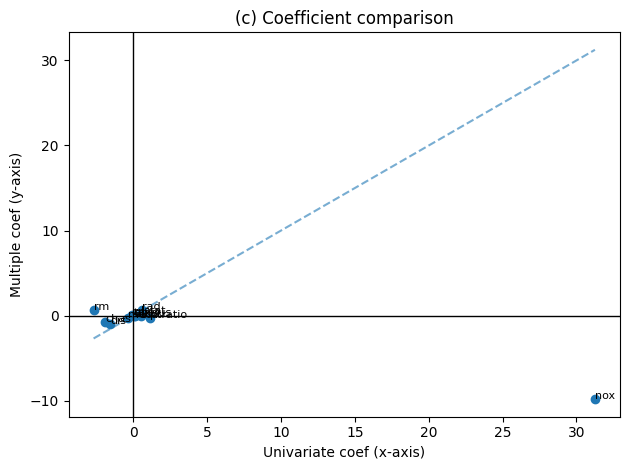

In [27]:
preds = Xcols

cmp = pd.DataFrame({"var": [v for v in Xcols if v != "Unnamed: 0"]})
cmp["beta_uni"]   = cmp["var"].map(dict(zip(uni_df["Predictor"], uni_df["Coefficient"])))
cmp["beta_multi"] = cmp["var"].map(m_full.params.to_dict())
cmp = cmp.dropna(subset=["beta_uni","beta_multi"])

plt.figure()
plt.axhline(0, color="k", lw=1); plt.axvline(0, color="k", lw=1)
xmin, xmax = cmp["beta_uni"].min(), cmp["beta_uni"].max()
plt.plot([xmin, xmax], [xmin, xmax], ls="--", alpha=0.6)
plt.scatter(cmp["beta_uni"], cmp["beta_multi"])
for _, r in cmp.iterrows():
    plt.text(r["beta_uni"], r["beta_multi"], r["var"], fontsize=8)
plt.xlabel("Univariate coef (x-axis)")
plt.ylabel("Multiple coef (y-axis)")
plt.title("(c) Coefficient comparison")
plt.tight_layout(); plt.show()


Points near y = x → univariate and multiple coefficients agree

large deviations or sign flips indicate changes after controlling for other variables

(d) Is there evidence of non-linear association between any of the
predictors and the response? To answer this question, for each
predictor X, fit a model of the form
Y= β0 + β1X + β2X^2 + β3X^3 + ϵ.

In [31]:
preds = [c for c in df.columns if c not in ("crim", "Unnamed: 0")]

from statsmodels.stats.anova import anova_lm
import pandas as pd
import numpy as np
import statsmodels.api as sm

poly_hits = []
for v in preds:
    Z = pd.DataFrame({v: df[v], f"{v}2": df[v]**2, f"{v}3": df[v]**3})
    m_poly = sm.OLS(y, sm.add_constant(Z)).fit()
    p2 = m_poly.pvalues.get(f"{v}2", np.nan)
    p3 = m_poly.pvalues.get(f"{v}3", np.nan)
    poly_hits.append({"var": v, "p_X2": p2, "p_X3": p3})

poly_df = pd.DataFrame(poly_hits).sort_values(["p_X2", "p_X3"])
print("(d) Evidence of nonlinearity (p-values for X^2, X^3) — excluding 'Unnamed: 0':")
print(poly_df.to_string(index=False))


(d) Evidence of nonlinearity (p-values for X^2, X^3) — excluding 'Unnamed: 0':
    var        p_X2        p_X3
   medv 3.26052e-18 1.04651e-12
    nox  6.8113e-15 6.96111e-16
    dis 4.94121e-12 1.08883e-08
  indus 3.42019e-10  1.1964e-12
ptratio  0.00411955  0.00630051
    age   0.0473773  0.00667992
  lstat   0.0645874    0.129891
     zn   0.0937505    0.229539
    tax    0.137468    0.243851
   chas    0.209435    0.209435
     rm    0.364109    0.508575
    rad     0.61301    0.482314


strong nonlinear associations for medv, nox, dis, indus, ptratio, age

No clear nonlinearity (p ≥ 0.05): lstat, zn, tax, chas, rm, rad.